# Simulating data with the Joint Model

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from tslearn.metrics import cdist_dtw
import umap

from leaspy.io.data import Data
from leaspy.datasets import load_dataset

## Import Data



In [2]:
df = load_dataset("simulated_data_for_joint")
display(df.head())
print(df.columns)

EVENT_TIME  EVENT_BOOL       Y0    Y1   Y2   Y3
ID  TIME                                                   
116 78.461        85.5           1  0.44444  0.04  0.0  0.0
    78.936        85.5           1  0.60000  0.00  0.0  0.2
    79.482        85.5           1  0.39267  0.04  0.0  0.2
    79.939        85.5           1  0.58511  0.00  0.0  0.0
    80.491        85.5           1  0.57044  0.00  0.0  0.0

Index(['EVENT_TIME', 'EVENT_BOOL', 'Y0', 'Y1', 'Y2', 'Y3'], dtype='object')


To use the Joint Model in Leaspy, your dataset must include the following columns:

1. **ID** : Patient identifier
2. **TIME** : Time of measurement
3. **EVENT_TIME** : Time of the event
4. **EVENT_BOOL** : Event indicator:
   - `1` if the event occurred
   - `0` if censored
   - `2` if a competing event occurred

For one patient, the event time and event bool are the same for each row.



## Joint Model Initialization and Fitting

In [3]:
from leaspy.models import JointModel

data = Data.from_dataframe(df, "joint")
model = JointModel(name="joint", nb_events=1)

In [ ]:
N = 1
model.fit(data, "mcmc_saem", seed=1312, n_iter=N, progress_bar=True, plot_periodicity=200, save_periodicity=100) 

 ==> Setting seed to 1312
|--------------------------------------------------|   0/10000 iterations

KeyboardInterrupt: 

In [ ]:
print(model.parameters)

{'betas_mean': tensor([[-0.0479, -0.1237],
        [-0.0198, -0.0707],
        [-0.1154, -0.0037]]), 'log_g_mean': tensor([0.1243, 3.2551, 2.8469, 1.4334]), 'log_rho_mean': tensor([-0.3370]), 'log_v0_mean': tensor([-3.2611, -4.2103, -4.0069, -2.9077]), 'n_log_nu_mean': tensor([-1.2348]), 'noise_std': tensor(0.0896, dtype=torch.float64), 'tau_mean': tensor([78.9875], dtype=torch.float64), 'tau_std': tensor([5.9391], dtype=torch.float64), 'xi_std': tensor([0.5410], dtype=torch.float64), 'zeta_mean': tensor([[ 0.2863],
        [-0.3635]])}


In [ ]:
model.save(f"../models/model_on_simulated_data_for_joint_{N}_iterations.json")

## Simulation

The parameters for simulating patient visits are defined.
These parameters specify the number of patients, the visit spacing, and the timing variability.

In [ ]:
visit_params = {
    "patient_number": 50,
    "visit_type": "random",
    "data": data
}

In [ ]:
df_sim = model.simulate(
    algorithm="joint_simulate",
    features=["Y0", "Y1", "Y2", "Y3"],
    visit_parameters=visit_params,
)

  [joint_simulate] Parameter 'first_visit_mean' not provided, estimated from data: -0.0
  [joint_simulate] Parameter 'first_visit_std' not provided, estimated from data: 5.7495
  [joint_simulate] Parameter 'time_follow_up_mean' not provided, estimated from data: 6.4194
  [joint_simulate] Parameter 'time_follow_up_std' not provided, estimated from data: 1.2036
  [joint_simulate] Parameter 'distance_visit_mean' not provided, estimated from data: 0.7795
  [joint_simulate] Parameter 'distance_visit_std' not provided, estimated from data: 0.2982
  [joint_simulate] Parameter 'min_spacing_between_visits' not provided, estimated from data: 0.328

Simulate with `joint_simulate` took: 1s


In [ ]:
df_sim = df_sim.data.to_dataframe()

display(df_sim)

,ID,TIME,EVENT_TIME,EVENT_BOOL,Y0,Y1,Y2,Y3
0,0,64.9,71.281614,0,0.210808,0.000000,0.000000e+00,0.000000e+00
1,0,65.6,71.281614,0,0.277051,0.000000,0.000000e+00,0.000000e+00
2,0,66.2,71.281614,0,0.231681,0.000000,0.000000e+00,0.000000e+00
3,0,66.9,71.281614,0,0.362477,0.000000,1.764015e-206,3.985105e-40
4,0,67.9,71.281614,0,0.316458,0.597430,1.725455e-01,7.298586e-03
...,...,...,...,...,...,...,...,...
240,49,84.7,89.255645,0,0.987404,0.327373,2.028920e-01,8.756852e-01
241,49,85.9,89.255645,0,0.996396,0.167312,3.153272e-01,8.431015e-01
242,49,86.9,89.255645,0,0.999780,0.317840,5.174987e-01,8.362826e-01
243,49,87.2,89.255645,0,0.919630,0.280236,5.208028e-01,8.406029e-01


In [ ]:
len(df_sim[df_sim["EVENT_BOOL"] == 0])

187

## Representation witb DTW + UMAP

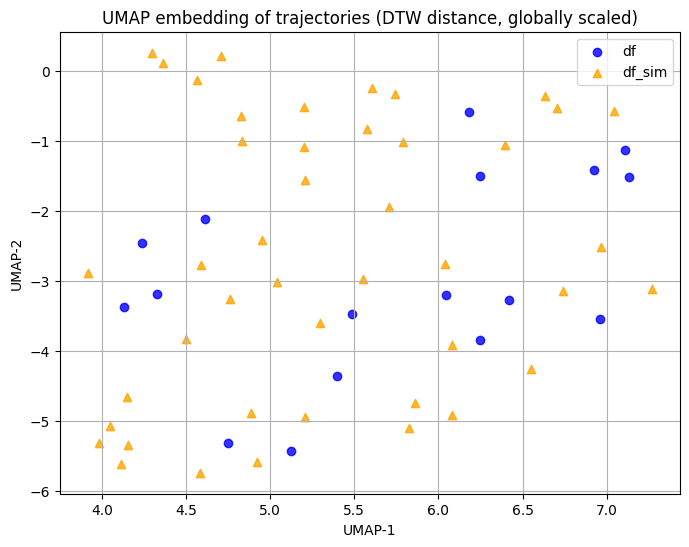

In [ ]:
# 1. Build trajectories
def build_trajectories(df):
    traj = []
    ids = []
    
    for id_, g in df.groupby('ID'):
        g = g.sort_values('TIME')
        X = g[['Y0','Y1','Y2','Y3']].values
        
        traj.append(X)
        ids.append(id_)
        
    return traj, ids

traj_df, ids_df = build_trajectories(df)
traj_sim, ids_sim = build_trajectories(df_sim)

# Combine
X_all = traj_df + traj_sim
labels = np.array(['df']*len(traj_df) + ['df_sim']*len(traj_sim))

# 2. Normalize globally (fit on all observations combined to preserve scale differences)
all_values = np.vstack(X_all)
scaler = StandardScaler()
scaler.fit(all_values)
scaled_traj = [scaler.transform(X) for X in X_all]

# 3. DTW distance matrix
D = cdist_dtw(scaled_traj)

# 4. UMAP on distance matrix
embedding = umap.UMAP(
    metric='precomputed',
    n_neighbors=15,
    min_dist=0.2,
    random_state=42
).fit_transform(D)

# 5. Plot
mask_df = labels == 'df'
mask_sim = labels == 'df_sim'

plt.figure(figsize=(8,6))

plt.scatter(
    embedding[mask_df, 0],
    embedding[mask_df, 1],
    c='blue',
    marker='o',
    label='df',
    alpha=0.8
)

plt.scatter(
    embedding[mask_sim, 0],
    embedding[mask_sim, 1],
    c='orange',
    marker='^',
    label='df_sim',
    alpha=0.8
)

plt.title("UMAP embedding of trajectories (DTW distance, globally scaled)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.grid(True)

plt.show()
